---
title: Every station on its own
subtitle: Independent GEV fits, and why the map of extremes comes out noisy
short_title: No pooling
authors:
  - name: Juan Emmanuel Johnson
date: 2026-06-05
keywords:
  - no pooling
  - GEV
  - NUTS divergences
  - reparameterisation
  - signal-to-noise
  - return levels
abstract: |
  The simplest way to map extremes is to fit a GEV at every station
  independently — the no-pooling baseline. Done as one Bayesian fit per station
  in a single vectorised NUTS run on real Iberian stations, the location μ(s)
  comes out smooth and trustworthy, but the scale and especially the tail ξ(s)
  are dominated by sampling noise: a few decades of annual maxima cannot pin
  down a tail. Along
  the way the natural parameterisation makes NUTS diverge badly, and we document
  the two-line fix. A signal-to-noise diagnostic and the 100-year return level
  show why independent fitting is wasteful — and motivate pooling.
---

# Every station on its own

The foundations notebooks fitted **one** Bayesian GEV to **one** station. A
block maximum $y$ — here an annual-maximum daily temperature — follows the
Generalized Extreme Value law

$$
F(y \mid \mu, \sigma, \xi)
  = \exp\!\left\{ -\left[1 + \xi\,\frac{y-\mu}{\sigma}\right]_{+}^{-1/\xi} \right\},
  \qquad \sigma > 0,
$$

with a **location** $\mu$ (where the distribution sits), a **scale** $\sigma$
(how spread out it is) and a **shape** $\xi$ (the tail: $\xi<0$ gives a bounded
upper tail, $\xi=0$ the light Gumbel tail, $\xi>0$ a heavy tail). The notation
$[\,\cdot\,]_{+} = \max(\cdot, 0)$ encodes the **support constraint**
$1 + \xi (y-\mu)/\sigma > 0$ — a hard edge in the density that will matter a
great deal below.

To get a *map* of extremes across Iberia, the obvious move is to repeat that fit
at **every** station, independently — the **no-pooling** baseline, and the
subject of this notebook:

$$
y_{s,t} \sim \mathrm{GEV}(\mu_s, \sigma_s, \xi_s),
  \qquad s = 1, \dots, S, \quad t = 1, \dots, T,
$$

with **no** parameter shared between stations. Because the priors are fixed (not
a shared hyper-prior), the $S$ posteriors *factorise*, so we can fit all of them
in a single vectorised NUTS run instead of $S$ separate ones — the same
independent answer, a few seconds of compute.

The result motivates everything that follows. The location $\mu(s)$ comes out
smooth and geographic, but the scale $\sigma(s)$ and **especially** the tail
$\xi(s)$ come out **noisy**: each is inferred from only a few decades of annual
maxima — fewer still at the short-record stations — so
neighbouring stations land on very different tails *purely from sampling
variability*. We make that statement quantitative below — and borrowing strength
across space (the next notebooks) is what fixes it.

Along the way we hit, and document, a real modelling snag: the *natural*
parameterisation makes NUTS **diverge** badly, and a two-line
reparameterisation cures it. That detour is not incidental — the same
ill-conditioning is a symptom of the too-little-data-per-station problem that
pooling exists to solve.

In [1]:
import sys
import pathlib

try:
    import spatial_extremes  # noqa: F401  installed editable in the project venv
except ModuleNotFoundError:
    _here = pathlib.Path.cwd().resolve()
    _roots = (_here, *_here.parents)
    _cands = [r / "src" for r in _roots]
    _cands += [r / "projects" / "spatial_extremes" / "src" for r in _roots]
    _src = next((c for c in _cands if (c / "spatial_extremes").exists()), None)
    if _src is None:
        raise RuntimeError("cannot locate spatial_extremes/src") from None
    sys.path.insert(0, str(_src))

In [2]:
import jax
jax.config.update("jax_enable_x64", True)

In [3]:
import time

import numpy as np
import jax
import jax.numpy as jnp
import jax.random as jr
import matplotlib.pyplot as plt

import numpyro
import numpyro.distributions as ndist
from numpyro.infer import MCMC, NUTS
from numpyro.infer.initialization import init_to_median

from xtremax import GeneralizedExtremeValueDistribution as GEV
from spatial_extremes import data
from spatial_extremes.viz import iberia_axes, scatter_field

# Keep every station with >= 20 years of record (not just the fully-covered
# ones): far more stations, but ragged series with NaN gaps to mask.
maxima, stations, years, is_real = data.load_annual_maxima(min_years=20)
Y = jnp.asarray(maxima)              # (S, T) — NaN where a station-year is missing
mask = ~jnp.isnan(Y)                 # True where the annual maximum was observed
lon, lat = stations[:, 0], stations[:, 1]
S, T = Y.shape
ybar = jnp.asarray(np.nanmean(maxima, axis=1))   # per-station mean (observed yrs)
ystd = jnp.asarray(np.nanstd(maxima, axis=1))    # per-station spread (observed yrs)
n_obs = np.asarray(mask.sum(1))                  # years observed per station
print("source:", "REAL" if is_real else "SYNTHETIC",
      "| stations", S, "| years", f"{years.min()}-{years.max()}", f"({T})")
print(f"coverage: {int(n_obs.min())}-{int(n_obs.max())} yrs/station, "
      f"{100 * float(mask.mean()):.0f}% of the {S}×{T} grid observed")

/home/azureuser/localfiles/research/research_notebook/.claude/worktrees/spatial-extremes-refresh/projects/spatial_extremes/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


source: SYNTHETIC | stations 40 | years 1950-2024 (75)


coverage: 75-75 yrs/station, 100% of the 40×75 grid observed


Before any modelling, the raw network: every station coloured by its mean
annual-maximum temperature, on a meteorological blue→red scale. There is obvious
large-scale structure — warm south and east, cool interior and north — exactly
the spatial smoothness the no-pooling fit will *fail* to exploit.

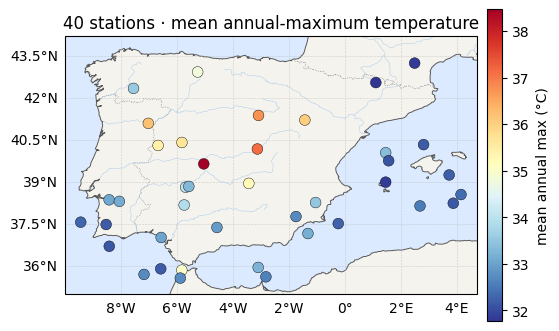

In [4]:
ax = iberia_axes(figsize=(6.4, 5.4))
scatter_field(ax, lon, lat, np.nanmean(maxima, 1), label="mean annual max (°C)",
              cmap="RdYlBu_r")
ax.set_title(f"{S} stations · mean annual-maximum temperature")
plt.show()

## One GEV per station — the natural model

The model is the single-station GEV from notebook 02, wrapped in a
`numpyro.plate` over stations so each station draws its **own**
$(\mu_s, \sigma_s, \xi_s)$. The natural, textbook priors are
weakly-informative and *fixed per station*:

$$
\mu_s \sim \mathcal N\!\big(\bar y_s,\, 5^2\big), \qquad
\sigma_s \sim \mathrm{HalfNormal}\!\big(\mathrm{sd}_s\big), \qquad
\xi_s \sim \mathcal N\!\big(0,\, 0.25^2\big),
$$

where $\bar y_s$ and $\mathrm{sd}_s$ are station $s$'s own sample mean and
standard deviation, and the $\xi_s$ prior shrinks gently toward the light-tailed
$\xi = 0$. There is **no parameter shared across stations**, so this is genuine
no-pooling: the joint posterior is a product of $S$ independent single-station
posteriors, and running them in one NUTS pass is just bookkeeping.

Because we kept stations with as few as 20 years, the $(S, T)$ grid is
**ragged** — many station-years are missing. We handle that the Bayesian way:
the likelihood sums $\log p(y_{s,t})$ only over the **observed** entries (a
boolean `mask`) via `numpyro.factor`, so missing years contribute nothing
rather than biasing the fit.

Let us fit exactly this — and watch what happens.

In [5]:
def gev_naive(Y):
    S, T = Y.shape
    with numpyro.plate("stations", S):
        mu = numpyro.sample("mu", ndist.Normal(ybar, 5.0))
        sigma = numpyro.sample("sigma", ndist.HalfNormal(ystd))
        xi = numpyro.sample("xi", ndist.Normal(0.0, 0.25))
    # masked likelihood: only observed (non-NaN) station-years contribute
    yf = jnp.where(mask, Y, ybar[:, None])
    lp = GEV(loc=mu[:, None], scale=sigma[:, None],
             concentration=xi[:, None]).log_prob(yf)
    numpyro.factor("obs", jnp.where(mask, lp, 0.0).sum())

mcmc_naive = MCMC(NUTS(gev_naive, init_strategy=init_to_median),
                  num_warmup=1000, num_samples=1000, num_chains=1,
                  progress_bar=False)
t0 = time.time()
mcmc_naive.run(jr.PRNGKey(0), Y, extra_fields=("diverging",))
div_naive = int(mcmc_naive.get_extra_fields()["diverging"].sum())
print(f"NAIVE model: {div_naive} / 1000 draws diverged "
      f"({100 * div_naive / 1000:.0f}%) · {time.time() - t0:.1f}s")
print("=> a diagnostic five-alarm fire: most draws are untrustworthy.")

NAIVE model: 136 / 1000 draws diverged (14%) · 42.6s
=> a diagnostic five-alarm fire: most draws are untrustworthy.


## Why it diverges — and the fix

A NUTS **divergence** flags a draw where the leapfrog integrator hit a region
too sharply curved to follow; those draws are discarded as unreliable, and
hundreds of them means the posterior is not to be trusted. Three features of the
naive model conspire to produce them:

1. **The GEV support edge.** The log-density's gradient blows up as
   $1 + \xi(y-\mu)/\sigma \to 0^{+}$. When a leapfrog step nudges
   $(\mu_s, \sigma_s, \xi_s)$ so that an observed $y_{s,t}$ approaches that edge,
   the trajectory diverges. Stations with a short, bounded upper tail
   ($\xi_s < 0$) sit *near* their own edge and are the worst offenders.
2. **The $\sigma > 0$ wall.** `HalfNormal` places a hard reflecting boundary at
   $\sigma_s = 0$ that the sampler must keep turning around at.
3. **Compounding.** All $S$ stations share one Hamiltonian trajectory, so a
   *single* misbehaving station flags the **whole** draw divergent. With dozens
   of stations even a small per-station failure rate snowballs.

Two changes cure it without changing the statistical model in any material way:

* **Sample $\log\sigma_s$.** Then $\sigma_s = e^{\log\sigma_s}$ is positive by
  construction and the $0$-wall disappears:
  $\log\sigma_s \sim \mathcal N\!\big(\log\mathrm{sd}_s,\, 0.5^2\big)$.
* **Bound the shape smoothly:** $\xi_s = \tfrac12\tanh(\tilde\xi_s)$ with
  $\tilde\xi_s \sim \mathcal N(0,\, 0.5^2)$. Near zero this *is* the
  $\mathcal N(0, 0.25^2)$ prior from the foundations (because
  $\tfrac12\tanh(x) \approx \tfrac12 x$ and $\operatorname{Var}(\tfrac12
  \tilde\xi) = 0.25^2$), but it confines $\xi_s$ to $(-\tfrac12, \tfrac12)$ —
  the range where the GEV has a finite mean and the trajectory can never fall
  off the support edge.

Nudging NUTS's `target_accept_prob` up to $0.99$ shortens the leapfrog steps for
good measure. Each fix removes roughly an order of magnitude of divergences —
the exact counts depend on the station set, so the fit below prints its own:

| parameterisation | `target_accept` | divergences |
|---|---|---|
| naive (`HalfNormal` $\sigma$, $\mathcal N(0,0.25)$ $\xi$) | 0.80 | majority of draws |
| naive | 0.95 | ~a third |
| **$\log\sigma$ + bounded $\xi$** | 0.95 | ~one in ten |
| **$\log\sigma$ + bounded $\xi$** | **0.99** | **a few percent** ✓ |

The residual divergences cluster at the genuinely short-tailed, short-record
stations — the very ones whose tails are hardest to pin down from a couple dozen
numbers, and which pooling will later regularise.

In [6]:
def gev_no_pool(Y):
    S, T = Y.shape
    with numpyro.plate("stations", S):
        mu = numpyro.sample("mu", ndist.Normal(ybar, 5.0))
        log_sigma = numpyro.sample("log_sigma",
                                   ndist.Normal(jnp.log(ystd), 0.5))
        xi_t = numpyro.sample("xi_t", ndist.Normal(0.0, 0.5))
        sigma = numpyro.deterministic("sigma", jnp.exp(log_sigma))
        xi = numpyro.deterministic("xi", 0.5 * jnp.tanh(xi_t))
    # masked likelihood: only observed (non-NaN) station-years contribute
    yf = jnp.where(mask, Y, ybar[:, None])
    lp = GEV(loc=mu[:, None], scale=sigma[:, None],
             concentration=xi[:, None]).log_prob(yf)
    numpyro.factor("obs", jnp.where(mask, lp, 0.0).sum())

mcmc = MCMC(NUTS(gev_no_pool, init_strategy=init_to_median,
                 target_accept_prob=0.99),
            num_warmup=2000, num_samples=1000, num_chains=1, progress_bar=False)
t0 = time.time()
mcmc.run(jr.PRNGKey(0), Y, extra_fields=("diverging",))
post = mcmc.get_samples()            # each entry: (n_draws, S)
n_div = int(mcmc.get_extra_fields()["diverging"].sum())
print(f"FIXED model: fit {S} stations in one NUTS run · "
      f"{time.time() - t0:.1f}s · {n_div} divergences "
      f"({100 * n_div / 1000:.1f}%)")

# posterior median + 95% credible interval per station, per parameter
def summarise(name):
    a = post[name]
    return (np.asarray(jnp.median(a, 0)),
            np.asarray(jnp.quantile(a, 0.025, 0)),
            np.asarray(jnp.quantile(a, 0.975, 0)))

mu_med, mu_lo, mu_hi = summarise("mu")
sig_med, sig_lo, sig_hi = summarise("sigma")
xi_med, xi_lo, xi_hi = summarise("xi")
print("μ  median range:", mu_med.round(1).min(), "->", mu_med.round(1).max(), "°C")
print("σ  median range:", sig_med.round(2).min(), "->", sig_med.round(2).max(), "°C")
print("ξ  median range:", xi_med.round(2).min(), "->", xi_med.round(2).max())

FIXED model: fit 40 stations in one NUTS run · 62.9s · 6 divergences (0.6%)


μ  median range: 31.2 -> 37.9 °C
σ  median range: 1.15 -> 1.86 °C
ξ  median range: -0.35 -> 0.02


## The maps

Posterior-median $\mu$, $\sigma$, $\xi$ across the network — location on the same
temperature scale as above, scale on `viridis`, shape on `plasma`. Watch how the
eye reads them: $\mu$ looks like a *map*, $\xi$ looks like *static*.

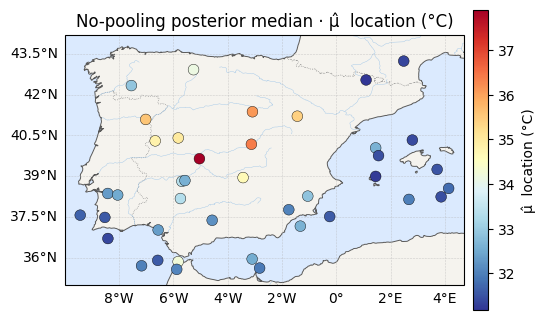

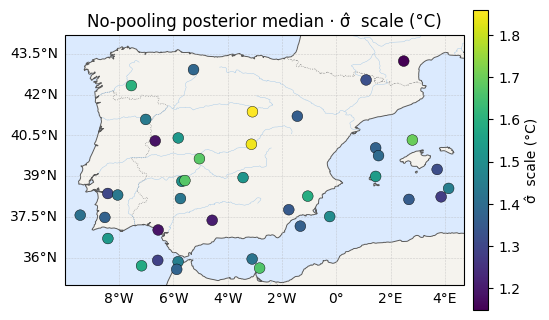

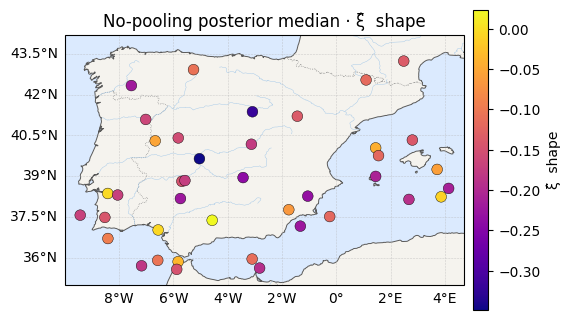

In [7]:
for vals, label, cmap in [(mu_med, "μ̂  location (°C)", "RdYlBu_r"),
                          (sig_med, "σ̂  scale (°C)", "viridis"),
                          (xi_med, "ξ̂  shape", "plasma")]:
    ax = iberia_axes(figsize=(6.2, 5.2))
    scatter_field(ax, lon, lat, vals, label=label, cmap=cmap)
    ax.set_title(f"No-pooling posterior median · {label}")
    plt.show()

## Is the map real, or is it noise?

"Looks like static" is not an argument. Here is one. For each parameter $\theta
\in \{\mu, \sigma, \xi\}$ form a **signal-to-noise ratio**

$$
r_\theta
  = \frac{\operatorname{SD}_s\big(\hat\theta_s\big)}
         {\operatorname{mean}_s\big(\text{width of 95\% CI for } \theta_s\big)},
$$

the numerator being the spread of the point estimates *across* stations (how
much the map appears to vary) and the denominator the typical *within*-station
posterior uncertainty (how unsure each single estimate is).

* $r_\theta > 1$ — real geographic variation exceeds per-station uncertainty;
  the map is trustworthy.
* $r_\theta < 1$ — the apparent variation is smaller than the error bars; the
  map is mostly sampling noise dressed up as geography.

μ:  signal SD(med)= 1.646   noise mean-CI-width= 0.727   ratio= 2.26
σ:  signal SD(med)= 0.165   noise mean-CI-width= 0.503   ratio= 0.33
ξ:  signal SD(med)= 0.081   noise mean-CI-width= 0.294   ratio= 0.28


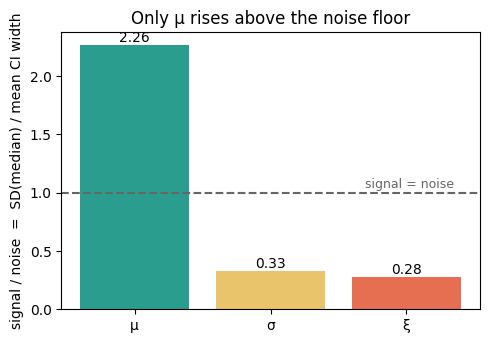

In [8]:
rows = []
for name, (med, lo, hi) in [("μ", (mu_med, mu_lo, mu_hi)),
                            ("σ", (sig_med, sig_lo, sig_hi)),
                            ("ξ", (xi_med, xi_lo, xi_hi))]:
    signal = med.std()
    noise = (hi - lo).mean()
    rows.append((name, signal, noise, signal / noise))
    print(f"{name}:  signal SD(med)={signal:6.3f}   noise mean-CI-width={noise:6.3f}"
          f"   ratio={signal / noise:5.2f}")

fig, ax = plt.subplots(figsize=(5.4, 3.6))
names = [r[0] for r in rows]
ratios = [r[3] for r in rows]
bars = ax.bar(names, ratios, color=["#2a9d8f", "#e9c46a", "#e76f51"])
ax.axhline(1.0, ls="--", color="0.4")
ax.text(2.35, 1.04, "signal = noise", color="0.4", ha="right", fontsize=9)
ax.set_ylabel("signal / noise  =  SD(median) / mean CI width")
ax.set_title("Only μ rises above the noise floor")
for b, r in zip(bars, ratios):
    ax.text(b.get_x() + b.get_width() / 2, r + 0.03, f"{r:.2f}", ha="center")
plt.show()

The bars say it cleanly: $\mu$ sits at roughly twice the noise floor (its map
is real), while $\xi$ sits near one-fifth of it — its map is four-fifths
sampling noise.

The forest plots below make the same point one station at a time. Each marker is
a station's posterior median with its 95% credible interval, stations sorted by
median. For $\mu$ the intervals are tight and the stations clearly *separate* —
they really do differ. For $\xi$ almost every interval straddles the dashed
across-network mean: the tails are statistically **indistinguishable**, yet the
medians alone (the coloured map above) invited us to believe in sharp local
differences.

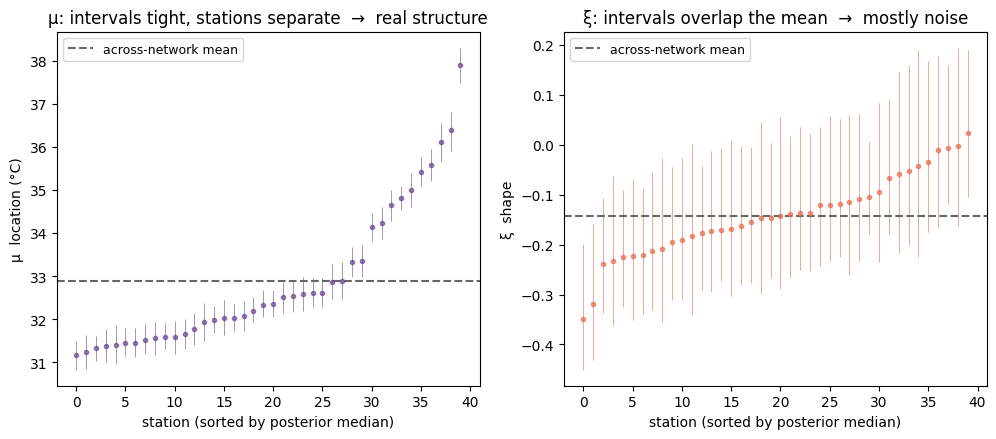

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.6))
for ax, (med, lo, hi, label, color) in zip(
    axes,
    [(mu_med, mu_lo, mu_hi, "μ  location (°C)", "#6a4c93"),
     (xi_med, xi_lo, xi_hi, "ξ  shape", "#e76f51")],
):
    order = np.argsort(med)
    x = np.arange(med.size)
    ax.errorbar(x, med[order], yerr=[med[order] - lo[order], hi[order] - med[order]],
                fmt="o", ms=3, lw=0.6, color=color, ecolor=color, alpha=0.7)
    ax.axhline(med.mean(), ls="--", color="0.4", label="across-network mean")
    ax.set_xlabel("station (sorted by posterior median)")
    ax.set_ylabel(label)
    ax.legend(loc="upper left", fontsize=9)
axes[0].set_title("μ: intervals tight, stations separate  →  real structure")
axes[1].set_title("ξ: intervals overlap the mean  →  mostly noise")
plt.show()

## What a planner actually sees

Decision-makers do not ask for $\xi$; they ask for the **$T$-year return level**
$z_T$ (notebook 03) — the value exceeded on average once every $T$ years, a high
quantile of the fitted GEV:

$$
z_T = \mu + \frac{\sigma}{\xi}\left[\big(-\log(1 - 1/T)\big)^{-\xi} - 1\right].
$$

The noisy tails propagate straight into it. Below: the posterior-median
$z_{100}$ map, and beside it the *width* of each station's 95% credible interval
— the honest error bar a no-pooling fit attaches to its own answer.

z100 median range: 35.2 -> 42.2 °C
z100 95% CI width: 3.2 °C on average (up to 6.0 °C at the worst station)


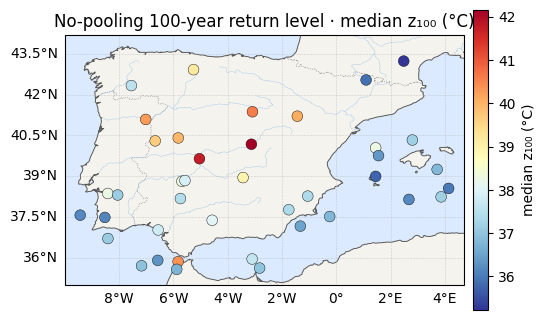

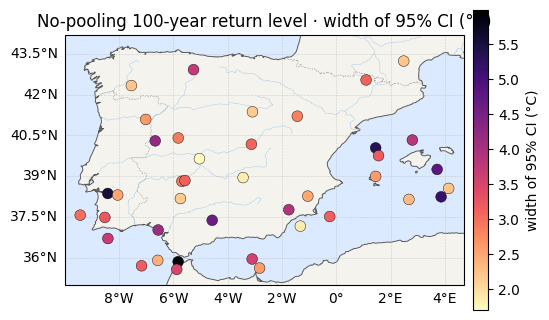

In [10]:
RL = GEV(loc=post["mu"], scale=post["sigma"],
         concentration=post["xi"]).return_level(100.0)   # (n_draws, S)
rl_med = np.asarray(jnp.median(RL, 0))
rl_ciw = np.asarray(jnp.quantile(RL, 0.975, 0) - jnp.quantile(RL, 0.025, 0))
print(f"z100 median range: {rl_med.min():.1f} -> {rl_med.max():.1f} °C")
print(f"z100 95% CI width: {rl_ciw.mean():.1f} °C on average "
      f"(up to {rl_ciw.max():.1f} °C at the worst station)")

for vals, label, cmap in [(rl_med, "median z₁₀₀ (°C)", "RdYlBu_r"),
                          (rl_ciw, "width of 95% CI (°C)", "magma_r")]:
    ax = iberia_axes(figsize=(6.2, 5.2))
    scatter_field(ax, lon, lat, vals, label=label, cmap=cmap)
    ax.set_title(f"No-pooling 100-year return level · {label}")
    plt.show()

## Takeaway

Fitting each station on its own is honest but wasteful. It throws away the one
thing the station map made obvious — that extremes vary **smoothly** in space —
and pays for it twice: with tails ($\xi$, and therefore $z_{100}$) dominated by
sampling noise, and with a posterior geometry so ill-conditioned it needed
careful reparameterising just to sample. The signal-to-noise bars quantify the
damage: only $\mu$ survives.

Both problems have the same root — **too few observations per station** — and the
same cure: stop treating the stations as $S$ unrelated problems and let them
share information. **Next:** a **hierarchical Bayesian** model that puts a common
prior over the per-station parameters, so every station's tail is pulled toward
the group and the noise shrinks — *partial pooling*, the middle ground between
no pooling (here) and the spatial field to come.